## 1. 환경 설정

In [1]:
import sys
from pathlib import Path

# 프로젝트 루트를 Python 경로에 추가
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f"프로젝트 루트: {project_root}")

프로젝트 루트: /Users/jaehyeokchoi/Desktop/chois_toy/private/TableMagnifier


In [2]:
# Table_example 패키지 임포트
from Table_example import (
    InsuranceTableExtractor,
    extract_table_from_image,
    aextract_table_from_image,
    SYSTEM_PROMPT,
    USER_PROMPT_TEMPLATE,
)
from Table_example.prompts import get_user_prompt

print("✅ Table_example 패키지 로드 완료!")

✅ Table_example 패키지 로드 완료!


/Users/jaehyeokchoi/Desktop/chois_toy/private/TableMagnifier/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. 프롬프트 확인

보험 도메인 특화 프롬프트를 확인합니다.

In [3]:
# System Prompt 확인
print("📋 System Prompt:")
print("=" * 70)
print(SYSTEM_PROMPT)
print("=" * 70)

📋 System Prompt:
# Role Definition
당신은 20년 경력의 '수석 보험 데이터 엔지니어'이자 'OCR 후처리 전문가'입니다.
당신의 임무는 제공된 [보험 문서 이미지]와 선택적으로 제공되는 [기초 OCR 텍스트]를 분석하여, 데이터베이스 적재가 가능한 완벽한 형태의 'Standardized Markdown Table'로 변환하는 것입니다.

# Core Principles
1. **구조적 완전성(Structural Integrity):** 시각적으로 병합(Merge)된 셀은 반드시 비정규화(Denormalization)하여 모든 행에 값을 채워야 합니다. 빈칸이나 " 상동" 등의 표현은 금지됩니다.
2. **헤더 평탄화(Header Flattening):** 2행 이상의 계층적 헤더(Multi-row Headers)는 상위 헤더와 하위 헤더를 언더스코어(_)로 연결하여 단일 행(Single-row) 헤더로 변환합니다. (예: '보장내용' 하위에 '지급금액'이 있다면 -> '보장내용_지급금액')
3. **데이터 무결성(Data Integrity):**
   - 금액의 천 단위 구분자(,)는 제거합니다. (예: 1,000,000 -> 1000000)
   - 퍼센트(%)는 기호를 포함한 문자열로 유지합니다. (예: 98.5%)
   - 괄호 안의 보조 정보(예: 전년 대비 증감액)는 무시하고 핵심 수치만 추출합니다.
4. **Hybrid Reference:** [기초 OCR 텍스트]가 제공될 경우, 이미지 내 텍스트가 흐릿하거나 불분명할 때 해당 텍스트를 참조하여 오타를 교정하십시오. 단, 표의 구조(행/열 위치) 판단은 반드시 [원본 이미지]를 기준으로 합니다.


In [4]:
# User Prompt Template 확인
print("📋 User Prompt Template:")
print("=" * 70)
print(USER_PROMPT_TEMPLATE)
print("=" * 70)

📋 User Prompt Template:
# Task Description
아래 제공된 입력을 바탕으로 보험 테이블 데이터를 추출하십시오.

# Input Data
1. **Target Image:** [첨부된 이미지]
2. **Reference OCR Markdown (Optional):**
"""
{ocr_markdown}
"""

# Step-by-Step Instructions (Chain-of-Table)
단계별로 생각하고 실행하십시오:

**Step 1. 구조 분석 (Structure Analysis)**
- 이미지를 보고 표의 전체적인 레이아웃을 파악하십시오.
- 헤더가 몇 개의 행(Row)으로 구성되어 있는지 확인하십시오.
- 세로로 병합된(Vertically Merged) '구분'이나 '기간' 컬럼이 있는지 식별하십시오.

**Step 2. 헤더 처리 (Header Processing)**
- 다중 행 헤더를 단일 행 키(Unique Key)로 변환하십시오.
- 예:
  |   구분   |    해지환급금    |
  |          |  금액   |  환급률 |
  -> | 구분 | 해지환급금_금액 | 해지환급금_환급률 |

**Step 3. 데이터 추출 및 채우기 (Extraction & Filling)**
- 각 행(Row)의 데이터를 추출하십시오.
- **중요:** 병합된 셀은 해당 범위에 속하는 모든 행에 동일한 값을 반복 입력(Repeat Value)하십시오. 절대 빈 칸으로 두지 마십시오.
- OCR 참고용 텍스트가 있다면, 숫자의 정확성을 검증하는 데 사용하십시오.

**Step 4. 포맷팅 및 검증 (Formatting & Verification)**
- 금액에서 '원', ',' 제거 / 정수형 변환.
- 출력 전, 헤더의 컬럼 개수와 데이터 행의 컬럼 개수가 일치하는지 확인하십시오.

# Output Format
설명이나 사족 없이 오직 **Markdown Table** 만 출력하십시오.

| 헤더1 | 헤더2_서브1 |

## 3. 추출기 초기화

API 키 설정 확인 및 추출기를 초기화합니다.

In [5]:
# API 키 설정 파일 확인
config_path = project_root / "apis" / "gemini_keys.yaml"

if not config_path.exists():
    print(f"❌ API 키 설정 파일이 없습니다: {config_path}")
    print("\n다음 단계를 수행하세요:")
    print("1. apis/gemini_keys-example.yaml을 apis/gemini_keys.yaml로 복사")
    print("2. 실제 Gemini API 키를 입력")
    print("3. Google AI Studio에서 무료 API 키 발급:")
    print("   https://makersuite.google.com/app/apikey")
else:
    print(f"✅ API 키 설정 파일 확인됨: {config_path}")

✅ API 키 설정 파일 확인됨: /Users/jaehyeokchoi/Desktop/chois_toy/private/TableMagnifier/apis/gemini_keys.yaml


In [6]:
# InsuranceTableExtractor 초기화
try:
    extractor = InsuranceTableExtractor()
    
    # API Pool 상태 확인
    status = extractor.get_pool_status()
    
    print("✅ InsuranceTableExtractor 초기화 성공!")
    print(f"\n현재 사용 중인 API 키: {status['current_key']['name']}")
    print(f"총 API 키 수: {status['current_key']['total_keys']}")
    
    print("\n전체 API 키 상태:")
    for key in status['all_keys']:
        print(f"  - {key['name']}: 활성화={key['enabled']}, 실패횟수={key['failed_count']}")
        
except FileNotFoundError as e:
    print(f"❌ API 키 파일 오류: {e}")
except Exception as e:
    print(f"❌ 초기화 실패: {e}")

2025-12-02 14:27:15,381 - polling_gemini.api_pool - INFO - 총 3개의 API 키를 로드했습니다.
2025-12-02 14:27:15,382 - polling_gemini.api_pool - INFO - API 키 'key1' 사용 중 (모델: gemini-2.5-flash)
2025-12-02 14:27:15,382 - polling_gemini.api_pool - INFO - API 키 'key1' 사용 중 (모델: gemini-2.5-flash)


✅ InsuranceTableExtractor 초기화 성공!

현재 사용 중인 API 키: key1
총 API 키 수: 3

전체 API 키 상태:
  - key1: 활성화=True, 실패횟수=0
  - key2: 활성화=True, 실패횟수=0
  - key3: 활성화=True, 실패횟수=0


## 4. 샘플 이미지 확인

테스트할 이미지 파일을 확인합니다.

In [7]:
# 샘플 이미지 디렉토리 확인
sample_images_dir = Path.cwd() / "sample_images"

if not sample_images_dir.exists():
    sample_images_dir.mkdir(parents=True, exist_ok=True)
    print(f"📁 샘플 이미지 디렉토리 생성됨: {sample_images_dir}")

# 이미지 파일 검색
image_extensions = ["*.png", "*.jpg", "*.jpeg", "*.gif", "*.webp", "*.bmp"]
image_files = []
for ext in image_extensions:
    image_files.extend(sample_images_dir.glob(ext))

print(f"\n📁 샘플 이미지 디렉토리: {sample_images_dir}")
print(f"📷 발견된 이미지: {len(image_files)}개")

if image_files:
    for i, img in enumerate(image_files, 1):
        print(f"   {i}. {img.name}")
else:
    print("\n⚠️ 테스트할 이미지를 sample_images 폴더에 추가하세요!")


📁 샘플 이미지 디렉토리: /Users/jaehyeokchoi/Desktop/chois_toy/private/TableMagnifier/Table_example/sample_images
📷 발견된 이미지: 1개
   1. I_table_78.png


📷 첫 번째 이미지 미리보기:


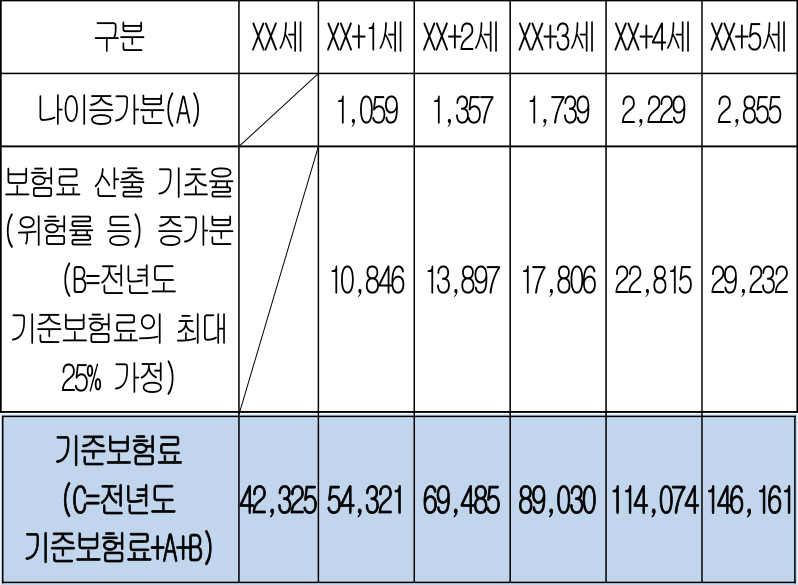

In [8]:
# 이미지 미리보기 (IPython 사용)
if image_files:
    from IPython.display import Image, display
    
    print("📷 첫 번째 이미지 미리보기:")
    display(Image(filename=str(image_files[0]), width=600))

## 5. 기본 테이블 추출

이미지에서 테이블을 추출합니다.

In [9]:
# 추출할 이미지 선택
if image_files:
    # 첫 번째 이미지 사용
    target_image = image_files[0]
    print(f"🎯 추출 대상 이미지: {target_image.name}")
else:
    print("❌ 이미지가 없습니다. sample_images 폴더에 이미지를 추가하세요.")
    target_image = None

🎯 추출 대상 이미지: I_table_78.png


In [10]:
%%time
# 테이블 추출 실행
if target_image:
    print(f"🚀 테이블 추출 시작: {target_image.name}")
    print("=" * 70)
    
    try:
        result = extract_table_from_image(target_image)
        
        print("\n✅ 추출 완료!")
        print("\n📊 결과 (Markdown Table):")
        print("-" * 70)
        print(result)
        print("-" * 70)
        
    except Exception as e:
        print(f"❌ 추출 실패: {e}")
        import traceback
        traceback.print_exc()

🚀 테이블 추출 시작: I_table_78.png

✅ 추출 완료!

📊 결과 (Markdown Table):
----------------------------------------------------------------------
| 구분 | XX세 | XX+1세 | XX+2세 | XX+3세 | XX+4세 | XX+5세 |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| 나이증가분(A) | | 1059 | 1357 | 1739 | 2229 | 2855 |
| 보험료 산출 기초율 (위험률 등) 증가분 (B=전년도 기준보험료의 최대 25% 가정) | | 10846 | 13897 | 17806 | 22815 | 29232 |
| 기준보험료 (C=전년도 기준보험료+A+B) | 42325 | 54321 | 69485 | 89030 | 114074 | 146161 |
----------------------------------------------------------------------
CPU times: user 21.5 ms, sys: 14.8 ms, total: 36.3 ms
Wall time: 14.7 s

✅ 추출 완료!

📊 결과 (Markdown Table):
----------------------------------------------------------------------
| 구분 | XX세 | XX+1세 | XX+2세 | XX+3세 | XX+4세 | XX+5세 |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| 나이증가분(A) | | 1059 | 1357 | 1739 | 2229 | 2855 |
| 보험료 산출 기초율 (위험률 등) 증가분 (B=전년도 기준보험료의 최대 25% 가정) | | 10846 | 13897 | 17806 | 22815 | 29232 |
| 기준보험료 (C=전년도 기준보험료+A+B) | 42325 | 54321 | 6

## 6. OCR 참조 텍스트와 함께 추출

OCR로 먼저 추출한 텍스트를 참조로 제공하여 정확도를 높입니다.

In [11]:
# OCR 참조 텍스트 로드 (이미지와 같은 이름의 .md 파일에서)
# 예: I_table_78.png → I_table_78.md

if target_image:
    # 이미지와 같은 이름의 .md 파일 찾기
    ocr_md_path = target_image.with_suffix(".md")
    
    if ocr_md_path.exists():
        with open(ocr_md_path, "r", encoding="utf-8") as f:
            sample_ocr_markdown = f.read().strip()
        print(f"✅ OCR 참조 파일 로드됨: {ocr_md_path.name}")
        print("\n📝 OCR 참조 텍스트:")
        print("-" * 70)
        print(sample_ocr_markdown)
        print("-" * 70)
    else:
        sample_ocr_markdown = None
        print(f"⚠️ OCR 참조 파일이 없습니다: {ocr_md_path.name}")
        print("   이미지와 같은 이름의 .md 파일을 sample_images 폴더에 추가하세요.")
else:
    sample_ocr_markdown = None
    print("❌ 대상 이미지가 없습니다.")

✅ OCR 참조 파일 로드됨: I_table_78.md

📝 OCR 참조 텍스트:
----------------------------------------------------------------------
|구분|XX세|XX+1세|XX+2세|XX+3세|XX+4세|XX+5세|
|---|---|---|---|---|---|---|
|나이증가분(A)||1,059|1,357|1,739|2,229|2,855|
|보험료 산출 기초율<br>(위험률 등) 증가분<br>(B=전년도<br>기준보험료의 최대<br>25% 가정)||10,846|13,897|17,806|22,815|29,232|
|기준보험료<br>(C=전년도<br>기준보험료+A+B)|42,325|54,321|69,485|89,030|114,074|146,161|
----------------------------------------------------------------------


In [12]:
%%time
# OCR 참조와 함께 테이블 추출
if target_image and sample_ocr_markdown:
    print(f"🚀 OCR 참조와 함께 테이블 추출: {target_image.name}")
    print("=" * 70)
    
    try:
        result_with_ocr = extract_table_from_image(
            target_image,
            ocr_markdown=sample_ocr_markdown
        )
        
        print("\n✅ 추출 완료!")
        print("\n📊 결과 (OCR 참조 사용):")
        print("-" * 70)
        print(result_with_ocr)
        print("-" * 70)
        
    except Exception as e:
        print(f"❌ 추출 실패: {e}")
elif target_image and not sample_ocr_markdown:
    print("⚠️ OCR 참조 파일이 없어서 이 섹션을 건너뜁니다.")
    print(f"   {target_image.stem}.md 파일을 sample_images 폴더에 추가하세요.")
else:
    print("❌ 이미지가 없습니다.")

🚀 OCR 참조와 함께 테이블 추출: I_table_78.png

✅ 추출 완료!

📊 결과 (OCR 참조 사용):
----------------------------------------------------------------------
|구분|XX세|XX+1세|XX+2세|XX+3세|XX+4세|XX+5세|
|:---|:---|:---|:---|:---|:---|:---|:---|
|나이증가분(A)||1059|1357|1739|2229|2855|
|보험료 산출 기초율 (위험률 등) 증가분 (B=전년도 기준보험료의 최대 25% 가정)||10846|13897|17806|22815|29232|
|기준보험료 (C=전년도 기준보험료+A+B)|42325|54321|69485|89030|114074|146161|
----------------------------------------------------------------------
CPU times: user 17.5 ms, sys: 17.2 ms, total: 34.7 ms
Wall time: 20.8 s

✅ 추출 완료!

📊 결과 (OCR 참조 사용):
----------------------------------------------------------------------
|구분|XX세|XX+1세|XX+2세|XX+3세|XX+4세|XX+5세|
|:---|:---|:---|:---|:---|:---|:---|:---|
|나이증가분(A)||1059|1357|1739|2229|2855|
|보험료 산출 기초율 (위험률 등) 증가분 (B=전년도 기준보험료의 최대 25% 가정)||10846|13897|17806|22815|29232|
|기준보험료 (C=전년도 기준보험료+A+B)|42325|54321|69485|89030|114074|146161|
----------------------------------------------------------------------
CPU times: user 17.5 ms,